In [1]:
import os
import cv2
from ultralytics import YOLO

# ============================================================
# 1. LOAD YOLO MODEL
# ============================================================
face_model = YOLO("yolov11n-face.pt")  # Ensure model file exists in working directory

# ============================================================
# 2. FACE EXTRACTION FROM A SINGLE VIDEO
# ============================================================
def extract_faces_from_video(video_path, output_folder, label, max_faces=10, frame_skip=5):
    """
    Extracts face crops from a video using YOLOv11 face detection.
    Args:
        video_path (str): Path to input video.
        output_folder (str): Directory to save face crops.
        label (str): Label or prefix for saved filenames.
        max_faces (int): Maximum number of face crops to save.
        frame_skip (int): Process every Nth frame for speed.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f" Cannot open video: {video_path}")
        return

    os.makedirs(output_folder, exist_ok=True)
    frame_count, saved_faces = 0, 0

    while cap.isOpened() and saved_faces < max_faces:
        ret, frame = cap.read()
        if not ret:
            break

        # Skip frames to reduce load
        if frame_count % frame_skip != 0:
            frame_count += 1
            continue

        # Face detection
        results = face_model.predict(frame, conf=0.6, verbose=False)
        for r in results:
            boxes = r.boxes.xyxy.cpu().numpy()
            for i, box in enumerate(boxes):
                x1, y1, x2, y2 = map(int, box)
                # Clip coordinates safely within frame
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(frame.shape[1], x2), min(frame.shape[0], y2)

                # Crop and validate face region
                face_crop = frame[y1:y2, x1:x2]
                if face_crop.size == 0:
                    continue

                # Save face image
                save_name = f"{label}_{frame_count:05d}_{i}.jpg"
                save_path = os.path.join(output_folder, save_name)
                cv2.imwrite(save_path, face_crop)
                saved_faces += 1

                if saved_faces >= max_faces:
                    break
            if saved_faces >= max_faces:
                break

        frame_count += 1

    cap.release()
    print(f" Extracted {saved_faces} faces from: {os.path.basename(video_path)} → {output_folder}")

# ============================================================
# 3. MATCH REAL AND FAKE VIDEOS AND EXTRACT
# ============================================================
def match_and_extract(real_dir, fake_dir, output_dir):
    """
    Matches real and fake videos by name, extracts faces from both.
    """
    os.makedirs(os.path.join(output_dir, "real"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "fake"), exist_ok=True)

    real_videos = [f for f in os.listdir(real_dir) if f.endswith(".mp4")]
    fake_videos = [f for f in os.listdir(fake_dir) if f.endswith(".mp4")]

    for real_video in real_videos:
        real_name = os.path.splitext(real_video)[0]
        matching_fake = next((f for f in fake_videos if real_name in f), None)

        if matching_fake:
            print(f" Pair found: {real_video} <--> {matching_fake}")
            extract_faces_from_video(
                os.path.join(real_dir, real_video),
                os.path.join(output_dir, "real"),
                real_name
            )
            extract_faces_from_video(
                os.path.join(fake_dir, matching_fake),
                os.path.join(output_dir, "fake"),
                real_name
            )
        else:
            print(f" No matching fake video found for: {real_video}")

# ============================================================
# 4. PROCESS ENTIRE DATASET
# ============================================================
def process_all_categories(base_path, output_base="AllExtractedFaces"):
    """
    Walks through all category subfolders in base_path and processes
    matched real/fake video pairs for face extraction.
    """
    for category in os.listdir(base_path):
        category_path = os.path.join(base_path, category)
        if not os.path.isdir(category_path):
            continue

        # Locate real and fake directories
        real_dir = None
        fake_dir = None
        for sub in os.listdir(category_path):
            sub_path = os.path.join(category_path, sub)
            if "real" in sub.lower():
                real_dir = sub_path
            elif "fake" in sub.lower():
                fake_dir = sub_path

        if real_dir and fake_dir:
            print(f"\n Processing Category: {category}")
            output_path = os.path.join(output_base, category.replace(" ", "_"))
            match_and_extract(real_dir, fake_dir, output_path)
        else:
            print(f" Skipping {category}: missing 'real' or 'fake' folder.")

# ============================================================
# 5. MAIN EXECUTION
# ============================================================
if __name__ == "__main__":
    dataset_root = "Dataset"  # Replace with your dataset folder
    process_all_categories(dataset_root)



🔍 Processing Category: Face swapping
🎯 Pair found: 1.mp4 <--> 1.mp4
✅ Extracted 10 faces from: 1.mp4 → AllExtractedFaces\Face_swapping\real
✅ Extracted 10 faces from: 1.mp4 → AllExtractedFaces\Face_swapping\fake
🎯 Pair found: 100.mp4 <--> 100.mp4
✅ Extracted 10 faces from: 100.mp4 → AllExtractedFaces\Face_swapping\real
✅ Extracted 10 faces from: 100.mp4 → AllExtractedFaces\Face_swapping\fake
🎯 Pair found: 101.mp4 <--> 101.mp4
✅ Extracted 10 faces from: 101.mp4 → AllExtractedFaces\Face_swapping\real
✅ Extracted 5 faces from: 101.mp4 → AllExtractedFaces\Face_swapping\fake
🎯 Pair found: 12.mp4 <--> 12.mp4
✅ Extracted 10 faces from: 12.mp4 → AllExtractedFaces\Face_swapping\real
✅ Extracted 10 faces from: 12.mp4 → AllExtractedFaces\Face_swapping\fake
🎯 Pair found: 13.mp4 <--> 13.mp4
✅ Extracted 10 faces from: 13.mp4 → AllExtractedFaces\Face_swapping\real
✅ Extracted 10 faces from: 13.mp4 → AllExtractedFaces\Face_swapping\fake
🎯 Pair found: 15.mp4 <--> 15.mp4
✅ Extracted 10 faces from: 15.m

 Using device: cuda
Classes found: ['fake', 'real']


C:\Users\Shreyanth\anaconda3\envs\pythonconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Shreyanth\anaconda3\envs\pythonconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Shreyanth\anaconda3\envs\pythonconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also u


 Training VGG16...
VGG16 -> Epoch [1/10] TrainAcc: 50.00% ValAcc: 48.73%
VGG16 -> Epoch [2/10] TrainAcc: 50.14% ValAcc: 48.73%
VGG16 -> Epoch [3/10] TrainAcc: 50.27% ValAcc: 48.73%
VGG16 -> Epoch [4/10] TrainAcc: 53.12% ValAcc: 51.27%
VGG16 -> Epoch [5/10] TrainAcc: 51.90% ValAcc: 51.27%
VGG16 -> Epoch [6/10] TrainAcc: 50.95% ValAcc: 51.27%
VGG16 -> Epoch [7/10] TrainAcc: 50.00% ValAcc: 51.27%
VGG16 -> Epoch [8/10] TrainAcc: 51.22% ValAcc: 52.53%
VGG16 -> Epoch [9/10] TrainAcc: 49.46% ValAcc: 56.96%
VGG16 -> Epoch [10/10] TrainAcc: 50.41% ValAcc: 56.33%
 Saved VGG16 model.

VGG16 - Classification Report:

              precision    recall  f1-score   support

        fake       0.48      0.88      0.62        69
        real       0.75      0.27      0.39        90

    accuracy                           0.53       159
   macro avg       0.62      0.58      0.51       159
weighted avg       0.63      0.53      0.49       159

ROC-AUC: 0.6390


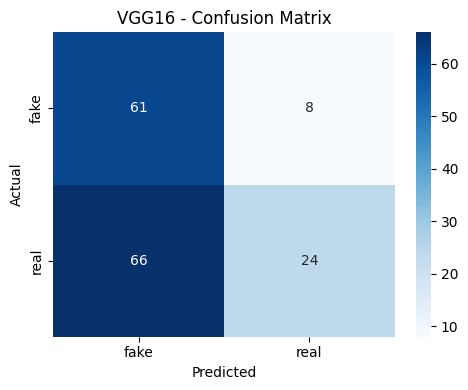

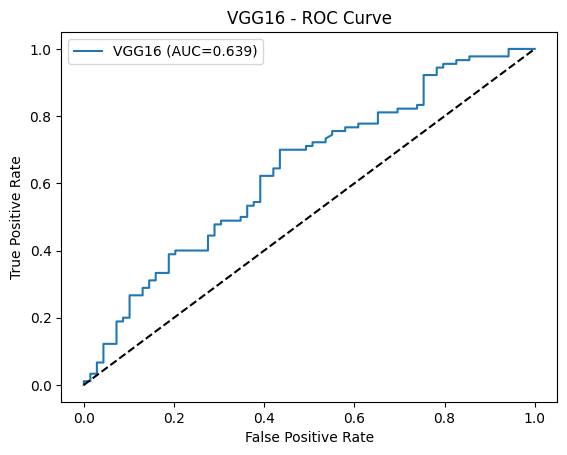


 Training CNN...
CNN -> Epoch [1/10] TrainAcc: 52.30% ValAcc: 52.53%
CNN -> Epoch [2/10] TrainAcc: 53.12% ValAcc: 55.06%
CNN -> Epoch [3/10] TrainAcc: 61.65% ValAcc: 60.13%
CNN -> Epoch [4/10] TrainAcc: 60.03% ValAcc: 63.29%
CNN -> Epoch [5/10] TrainAcc: 60.03% ValAcc: 70.89%
CNN -> Epoch [6/10] TrainAcc: 62.60% ValAcc: 63.29%
CNN -> Epoch [7/10] TrainAcc: 61.92% ValAcc: 65.19%
CNN -> Epoch [8/10] TrainAcc: 62.06% ValAcc: 65.19%
CNN -> Epoch [9/10] TrainAcc: 63.55% ValAcc: 67.09%
CNN -> Epoch [10/10] TrainAcc: 62.60% ValAcc: 62.66%
 Saved CNN model.

CNN - Classification Report:

              precision    recall  f1-score   support

        fake       0.56      0.70      0.62        69
        real       0.72      0.59      0.65        90

    accuracy                           0.64       159
   macro avg       0.64      0.64      0.63       159
weighted avg       0.65      0.64      0.64       159

ROC-AUC: 0.6556


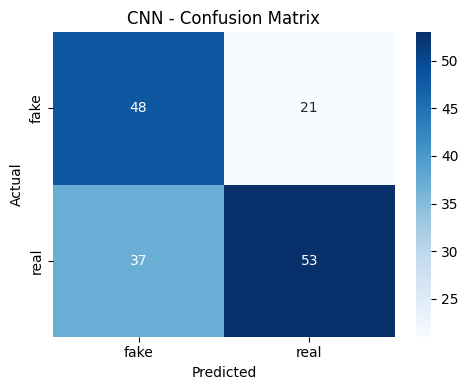

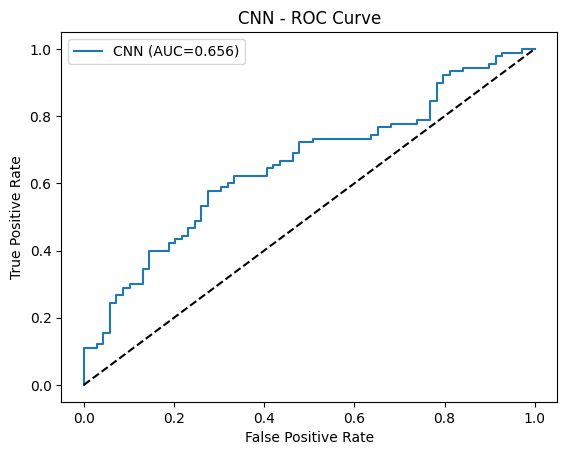


 Training ResNet18...
ResNet18 -> Epoch [1/10] TrainAcc: 60.70% ValAcc: 70.89%
ResNet18 -> Epoch [2/10] TrainAcc: 75.20% ValAcc: 70.25%
ResNet18 -> Epoch [3/10] TrainAcc: 74.25% ValAcc: 72.15%
ResNet18 -> Epoch [4/10] TrainAcc: 81.17% ValAcc: 77.85%
ResNet18 -> Epoch [5/10] TrainAcc: 73.85% ValAcc: 64.56%
ResNet18 -> Epoch [6/10] TrainAcc: 84.82% ValAcc: 80.38%
ResNet18 -> Epoch [7/10] TrainAcc: 87.40% ValAcc: 86.71%
ResNet18 -> Epoch [8/10] TrainAcc: 89.30% ValAcc: 82.28%
ResNet18 -> Epoch [9/10] TrainAcc: 90.24% ValAcc: 86.08%
ResNet18 -> Epoch [10/10] TrainAcc: 92.28% ValAcc: 84.18%
 Saved ResNet18 model.

ResNet18 - Classification Report:

              precision    recall  f1-score   support

        fake       0.75      0.88      0.81        69
        real       0.90      0.78      0.83        90

    accuracy                           0.82       159
   macro avg       0.83      0.83      0.82       159
weighted avg       0.83      0.82      0.82       159

ROC-AUC: 0.9391


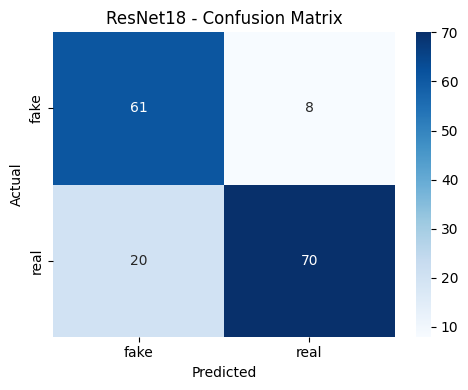

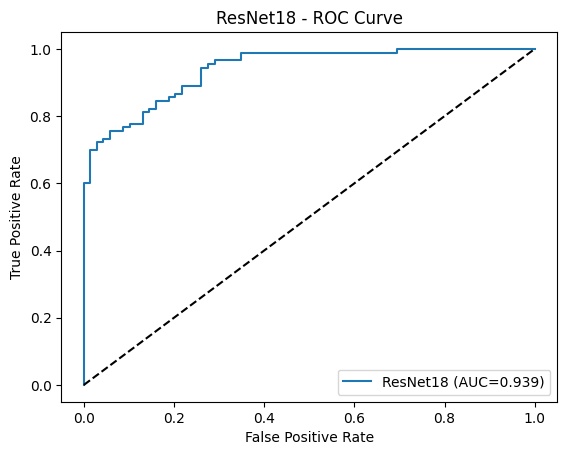

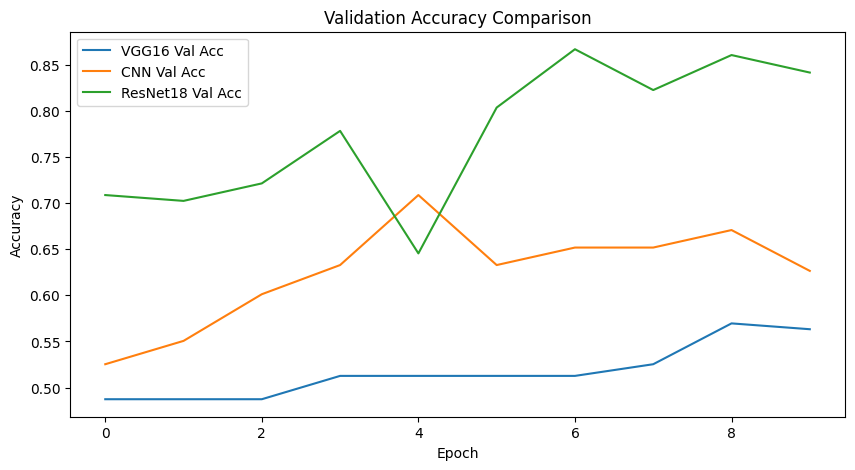

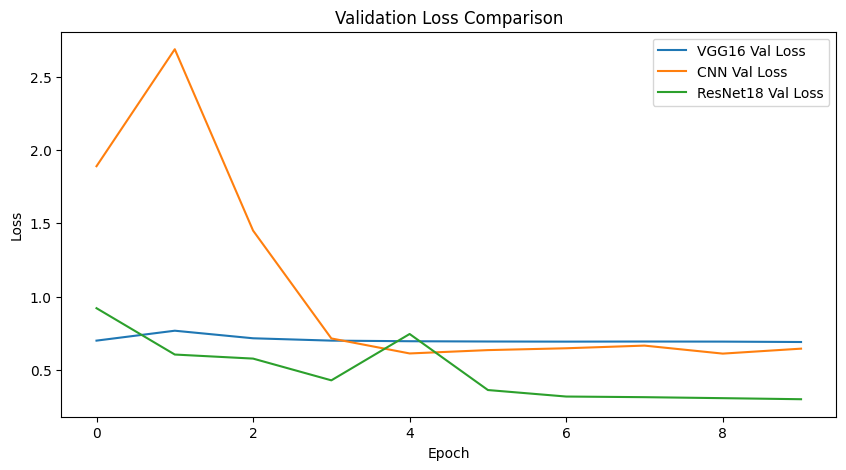

In [5]:
import os
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import tensorflow as tf

# ============================================================
# SETUP
# ============================================================
root_dir = r"D:\Accurate Projects\2025-2026\Deep Fake Video with AI detection\AllExtractedFaces\Face_swapping"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
tf.random.set_seed(SEED)

# ============================================================
# MODEL DEFINITIONS
# ============================================================
class TunedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.classifier(x)

def get_models():
    cnn = TunedCNN()
    resnet = models.resnet18(pretrained=True)
    resnet.fc = nn.Linear(resnet.fc.in_features, 2)
    vgg = models.vgg16(pretrained=True)
    vgg.classifier[6] = nn.Linear(vgg.classifier[6].in_features, 2)
    return {"VGG16": vgg, "CNN": cnn, "ResNet18": resnet}


# ============================================================
# TRAINING FUNCTION
# ============================================================
def train_model(model, train_loader, val_loader, name, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    train_loss, val_loss, train_acc, val_acc = [], [], [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        train_acc.append(correct / total)
        train_loss.append(total_loss / len(train_loader))

        # Validation
        model.eval()
        val_correct, val_total, val_total_loss = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                _, pred = torch.max(outputs, 1)
                val_total_loss += loss.item()
                val_correct += (pred == labels).sum().item()
                val_total += labels.size(0)

        val_acc.append(val_correct / val_total)
        val_loss.append(val_total_loss / len(val_loader))
        scheduler.step()

        print(f"{name} -> Epoch [{epoch+1}/{epochs}] "
              f"TrainAcc: {train_acc[-1]*100:.2f}% ValAcc: {val_acc[-1]*100:.2f}%")

    return model, (train_loss, val_loss, train_acc, val_acc)

# ============================================================
# EVALUATION
# ============================================================
def evaluate_model(model, data_loader, name, class_names):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    print(f"\n{name} - Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # ROC-AUC
    try:
        auc = roc_auc_score(all_labels, all_probs)
        print(f"ROC-AUC: {auc:.4f}")
    except:
        auc = None

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    if auc:
        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        plt.figure()
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{name} - ROC Curve")
        plt.legend()
        plt.show()

# ============================================================
# MAIN EXECUTION
# ============================================================

if __name__ == "__main__":
    root_dir = r"D:\Accurate Projects\2025-2026\Deep Fake Video with AI detection\AllExtractedFaces\Face_swapping"
    dataset = ImageFolder(root_dir, transform=transform)
    class_names = dataset.classes
    print(f"Classes found: {class_names}")

    # Split dataset
    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

    models_dict = get_models()
    results = {}

    for name, model in models_dict.items():
        print(f"\n Training {name}...")
        model, metrics = train_model(model, train_loader, val_loader, name)
        results[name] = metrics

        torch.save(model.state_dict(), f"{name.lower()}_model.pth")
        print(f" Saved {name} model.")

        evaluate_model(model, test_loader, name, class_names)

    # Comparison Plots
    plt.figure(figsize=(10, 5))
    for name, (train_loss, val_loss, train_acc, val_acc) in results.items():
        plt.plot(val_acc, label=f'{name} Val Acc')
    plt.title("Validation Accuracy Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    for name, (train_loss, val_loss, train_acc, val_acc) in results.items():
        plt.plot(val_loss, label=f'{name} Val Loss')
    plt.title("Validation Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
